# Feature extraction and price prediction for mobile phones

In [77]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_excel("Data.xlsx")

In [3]:
df.head()

,S,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [4]:
df=df.drop(columns=['S'])

In [5]:
df.head()

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [6]:
df.shape

(541, 11)

In [7]:
df.columns

Index(['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera',
       'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize'],
      dtype='object')

# Data Basic Cleaning 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    object 
 1   Colour         541 non-null    object 
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    object 
 6   Front Camera   541 non-null    object 
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    object 
 10  Prize          541 non-null    int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 46.6+ KB


In [9]:
# Before dropping
df.duplicated().sum()

np.int64(10)

In [10]:
# removing duplicated values
df = df.drop_duplicates()
# after removing duplicates values
df.duplicated().sum()


np.int64(0)

# Univariate Analysis

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Memory,531.0,110.915254,60.872883,16.0,64.00,128.00,128.00,256.00
RAM,531.0,5.401130,1.991283,2.0,4.00,6.00,8.00,8.00
Battery,531.0,4873.877589,765.883129,800.0,5000.00,5000.00,5000.00,7000.00
AI Lens,531.0,0.064030,0.245037,0.0,0.00,0.00,0.00,1.00
Mobile Height,531.0,16.450019,2.494246,4.5,16.51,16.71,16.94,41.94
Price,531.0,16305.775895,10847.038354,920.0,9368.00,13999.00,19338.50,80999.00


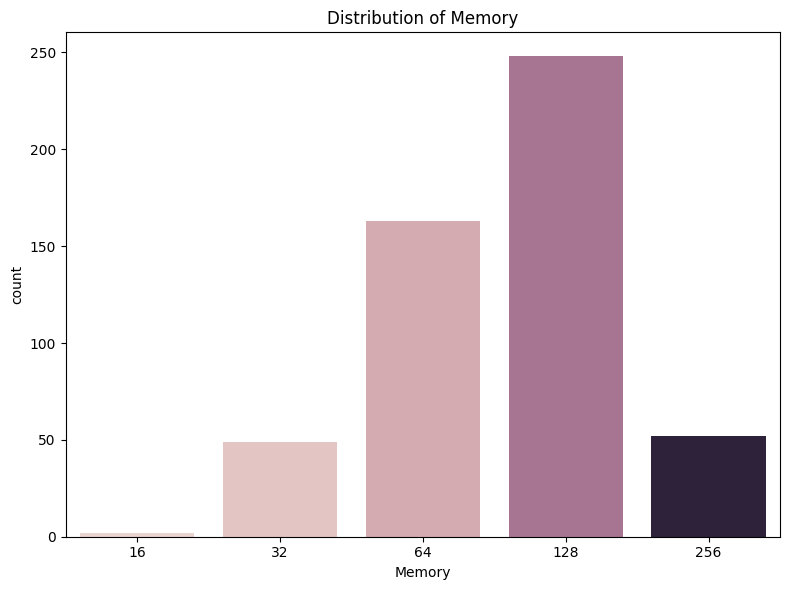

Memory
128    248
64     163
256     52
32      49
16       2
Name: count, dtype: int64

In [78]:
# Distribution of Memory
plt.figure(figsize=(8,6))

ax1 = sns.countplot(data=df, x='Memory', hue='Memory', legend=False)
plt.title("Distribution of Memory")
plt.tight_layout()
plt.show()
display(df['Memory'].value_counts())


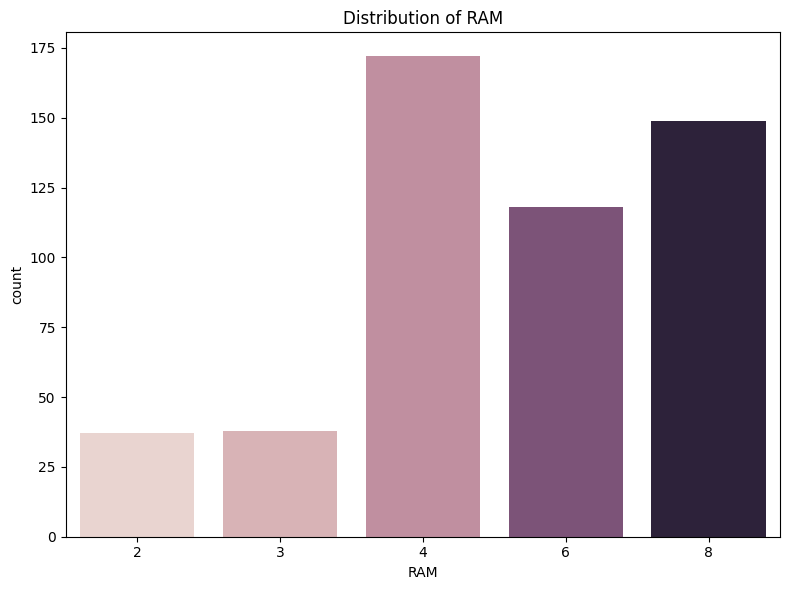

RAM
4    172
8    149
6    118
3     38
2     37
Name: count, dtype: int64

In [80]:
# Distribution of RAM
plt.figure(figsize=(8,6))
ax1 = sns.countplot(data=df, x='RAM', hue='RAM', legend=False)
plt.title("Distribution of RAM")
plt.tight_layout()
plt.show()
display(df['RAM'].value_counts())

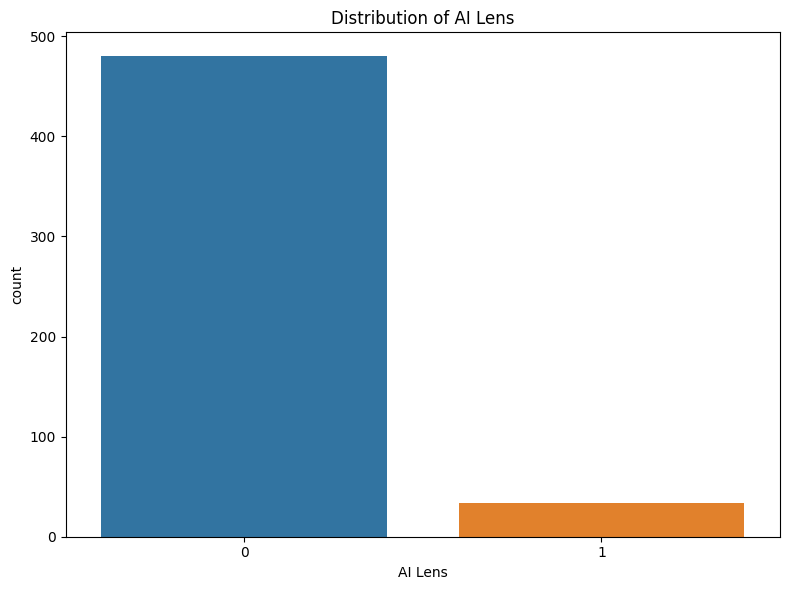

AI Lens
0    480
1     34
Name: count, dtype: int64

In [81]:
# Distribution of AI Lens
plt.figure(figsize=(8,6))
ax1 = sns.countplot(data=df, x='AI Lens', hue='AI Lens', legend=False)
plt.title("Distribution of AI Lens")
plt.tight_layout()
plt.show()
display(df['AI Lens'].value_counts())

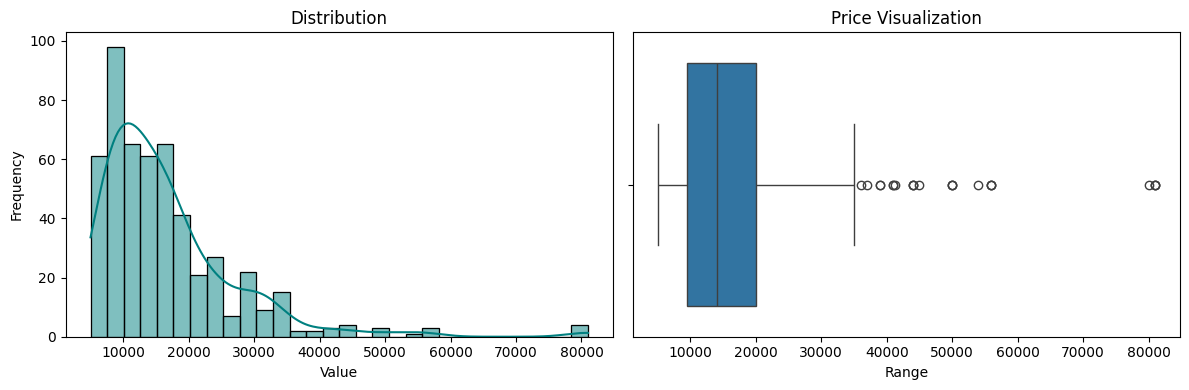

In [82]:
# Distribution of Prize
fig = plt.figure(figsize=(12, 4))

# Create Histogram
plt.subplot(1, 2, 1)
ax1 = sns.histplot(data=df, x='Price', color='teal', kde=True)
ax1.set_title('Distribution')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

plt.subplot(1, 2, 2)
ax2 = sns.boxplot(data=df, x='Price')
ax2.set_title('Outliars')
ax2.set_xlabel('Range')

plt.title("Price Visualization")
plt.tight_layout()
plt.show()

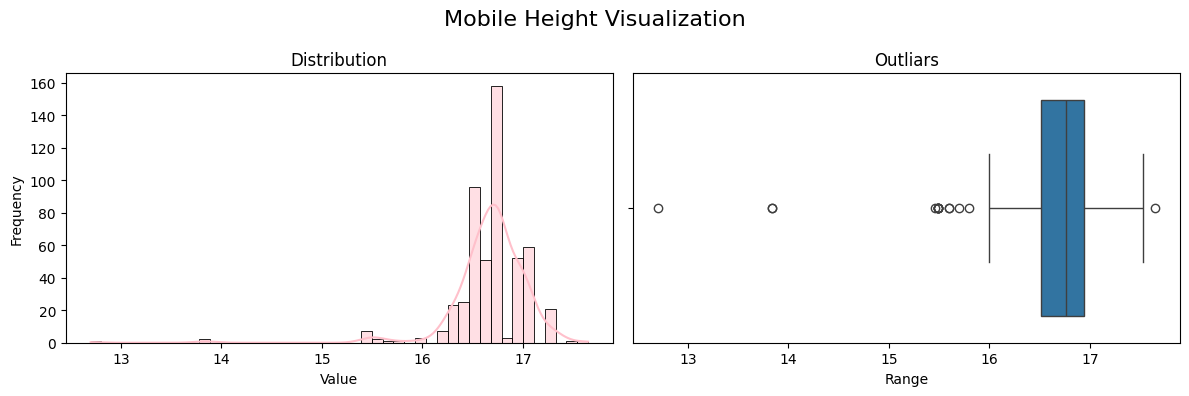

In [83]:
# Mobile Height
fig = plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 2, 1)
ax1 = sns.histplot(data=df, x='Mobile Height', color='pink', kde=True)
ax1.set_title('Distribution')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

plt.subplot(1, 2, 2)
ax2 = sns.boxplot(data=df, x='Mobile Height')
ax2.set_title('Outliars')
ax2.set_xlabel('Range')

fig.suptitle("Mobile Height Visualization", fontsize=16)
plt.tight_layout()
plt.show()

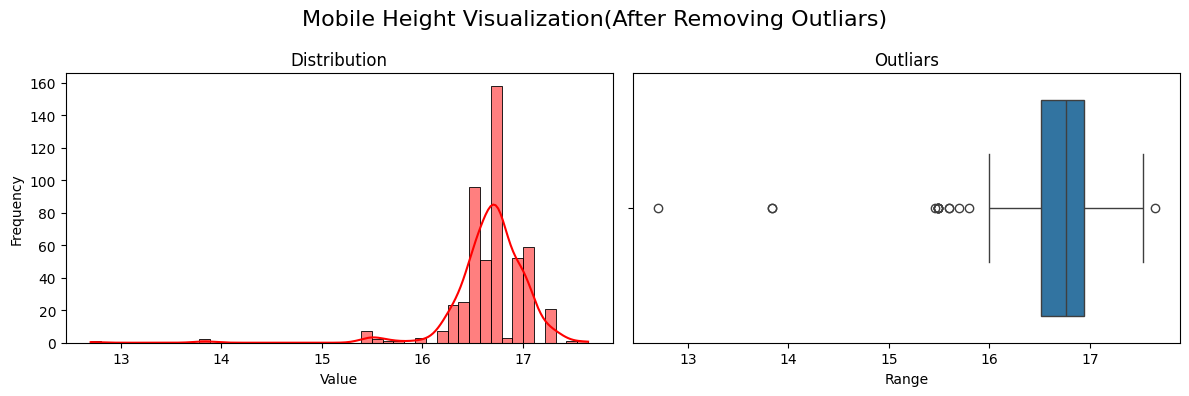

In [84]:
# After cleaning and removing outliars
df = df[(df['Mobile Height'] > 10) & (df['Mobile Height'] < 20)].copy()
fig = plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 2, 1)
ax1 = sns.histplot(data=df, x='Mobile Height', color='red', kde=True)
ax1.set_title('Distribution')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

plt.subplot(1, 2, 2)
ax2 = sns.boxplot(data=df, x='Mobile Height')
ax2.set_title('Outliars')
ax2.set_xlabel('Range')

fig.suptitle("Mobile Height Visualization(After Removing Outliars)", fontsize=16)
plt.tight_layout()
plt.show()

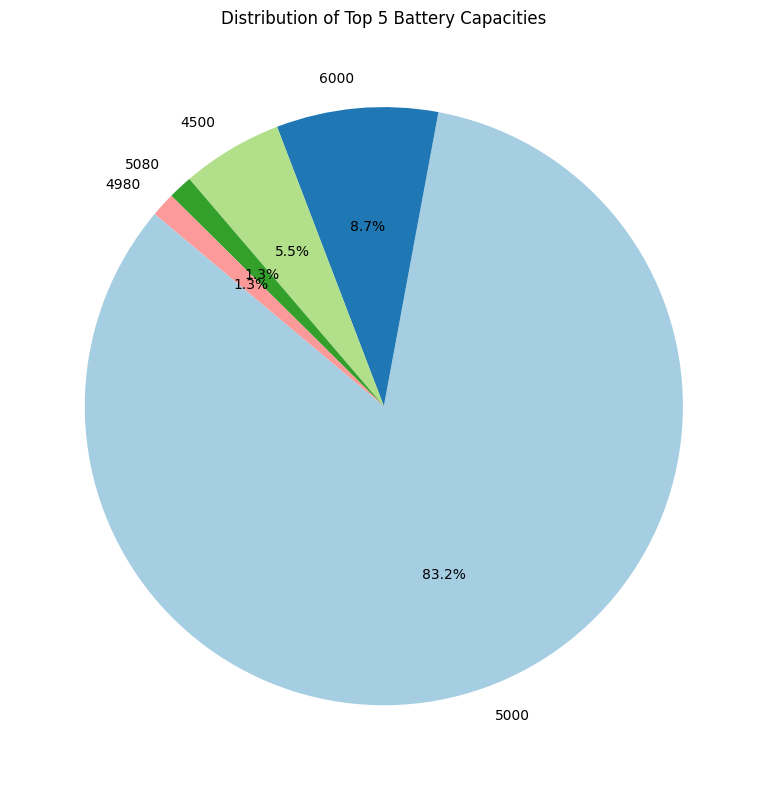

In [93]:
# Distribution of Top 5 Battery 
top_batteries = df['Battery'].value_counts().head()
plt.figure(figsize=(8, 8))
# Pie Chart
plt.pie(top_batteries, labels=top_batteries.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Top 5 Battery Capacities')
plt.tight_layout()
plt.show()

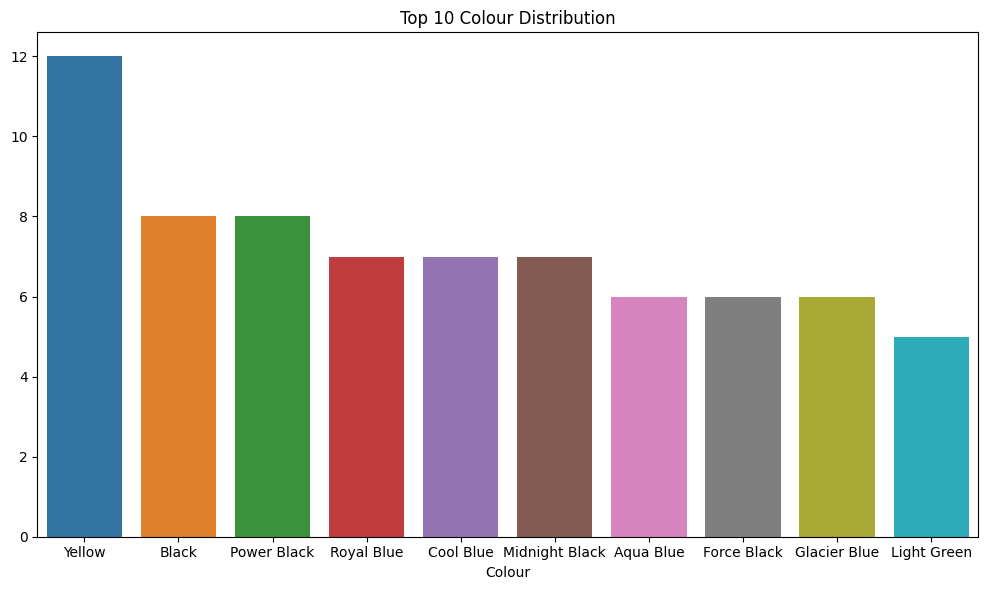

Colour
Yellow            12
Black              8
Power Black        8
Royal Blue         7
Cool Blue          7
Midnight Black     7
Aqua Blue          6
Force Black        6
Glacier Blue       6
Light Green        5
Name: count, dtype: int64

In [94]:
# Color
fig = plt.figure(figsize=(10, 6))
top10_df = df['Colour'].value_counts().head(10)

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Top 10 Colour Distribution")

plt.tight_layout()
plt.show()
display(top10_df)

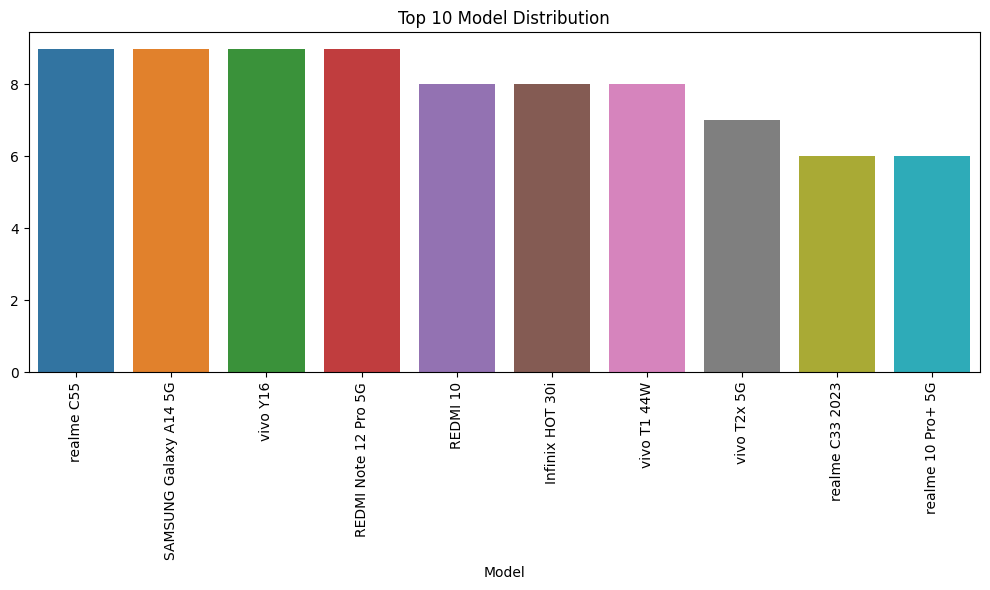

Model
realme C55               9
SAMSUNG Galaxy A14 5G    9
vivo Y16                 9
REDMI Note 12 Pro 5G     9
REDMI 10                 8
Infinix HOT 30i          8
vivo T1 44W              8
vivo T2x 5G              7
realme C33 2023          6
realme 10 Pro+ 5G        6
Name: count, dtype: int64

In [95]:
# Model
fig = plt.figure(figsize=(10, 6))
top10_df = df['Model'].value_counts().head(10)

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Top 10 Model Distribution")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()
display(top10_df)

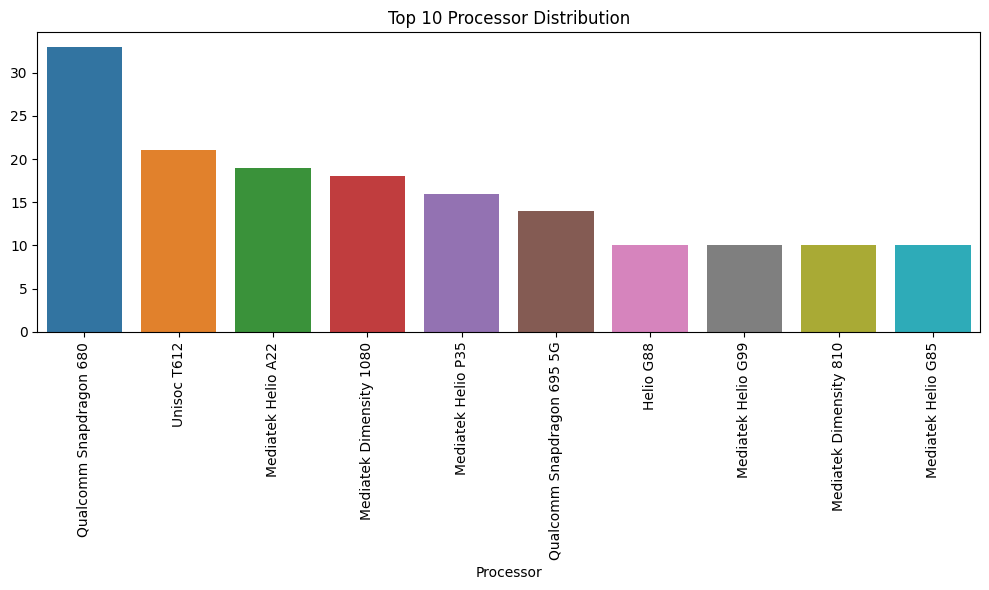

Processor
Qualcomm Snapdragon 680       33
Unisoc T612                   21
Mediatek Helio A22            19
Mediatek Dimensity 1080       18
Mediatek Helio P35            16
Qualcomm Snapdragon 695 5G    14
Helio G88                     10
Mediatek Helio G99            10
Mediatek Dimensity 810        10
Mediatek Helio G85            10
Name: count, dtype: int64

In [96]:
# Processor
fig = plt.figure(figsize=(10, 6))
top10_df = df['Processor'].value_counts().head(10)

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Top 10 Processor Distribution")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()
display(top10_df)

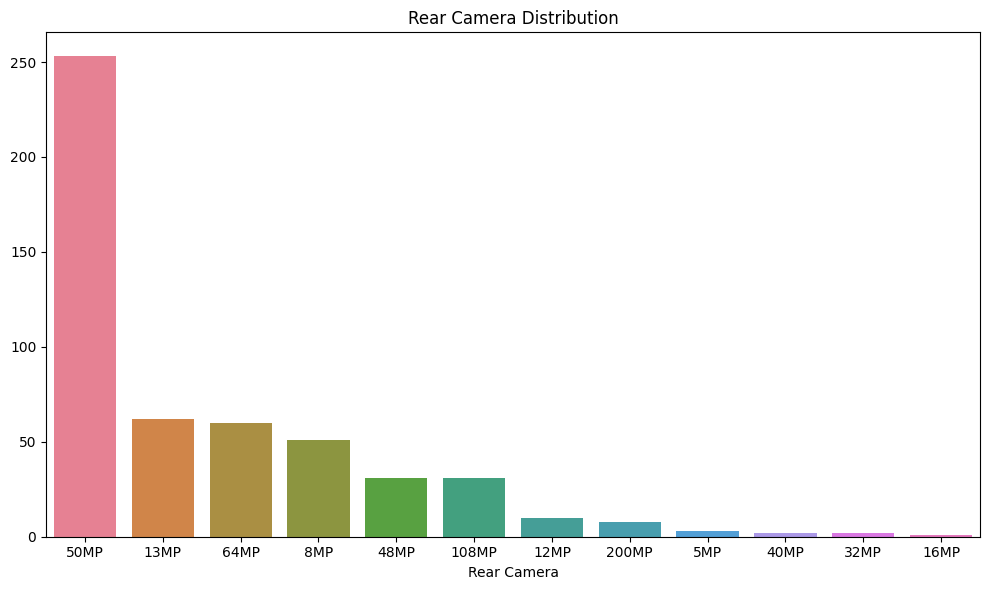

Rear Camera
50MP     253
13MP      62
64MP      60
8MP       51
48MP      31
108MP     31
12MP      10
200MP      8
5MP        3
40MP       2
32MP       2
16MP       1
Name: count, dtype: int64

In [97]:
# Rear Camera
fig = plt.figure(figsize=(10, 6))
top10_df = df['Rear Camera'].value_counts()

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Rear Camera Distribution")

plt.tight_layout()
plt.show()
display(top10_df)

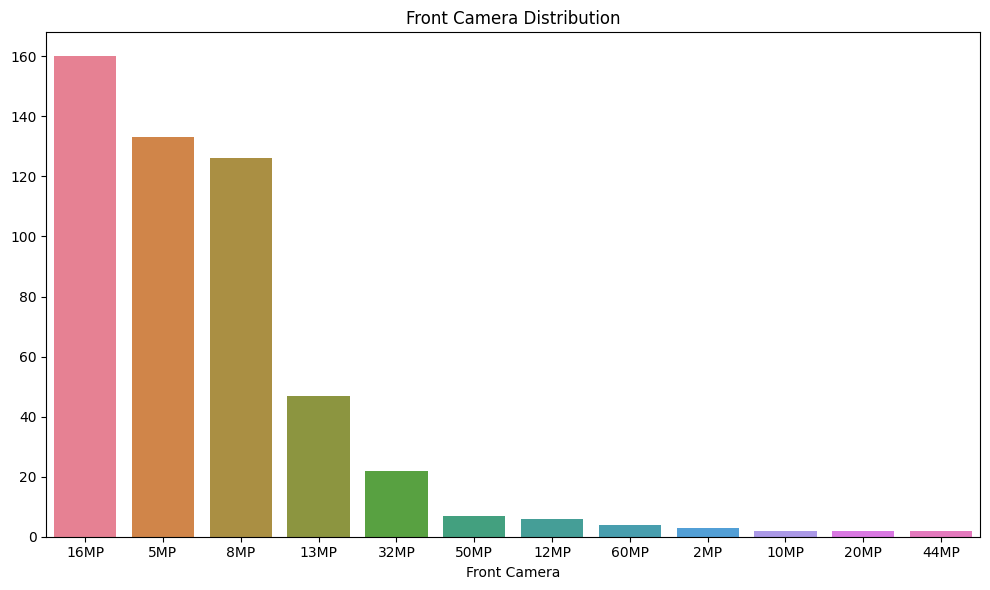

Front Camera
16MP    160
5MP     133
8MP     126
13MP     47
32MP     22
50MP      7
12MP      6
60MP      4
2MP       3
10MP      2
20MP      2
44MP      2
Name: count, dtype: int64

In [98]:
# Front Camera
fig = plt.figure(figsize=(10, 6))
top10_df = df['Front Camera'].value_counts()

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Front Camera Distribution")

plt.tight_layout()
plt.show()
display(top10_df)

Bivariate Analysis

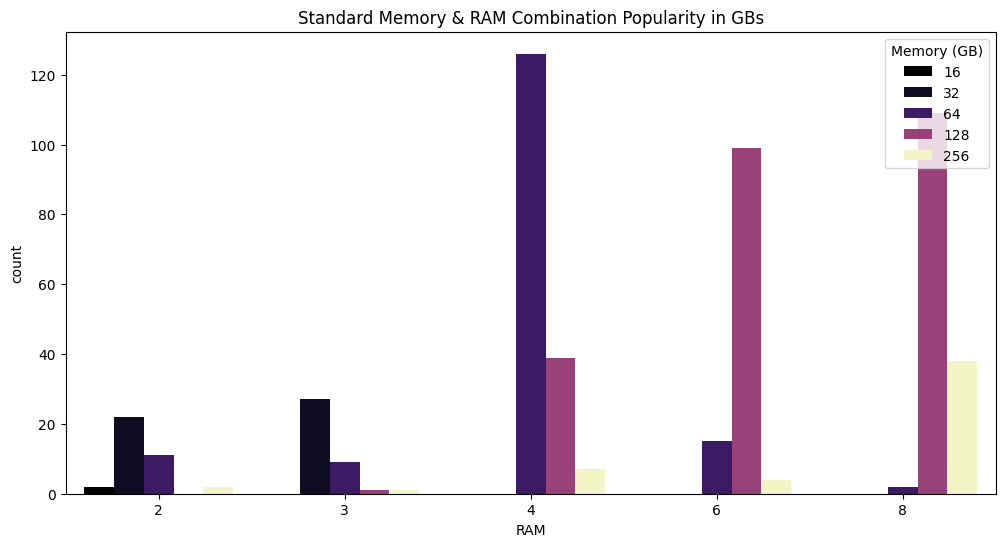

In [99]:
# RAM vs Memory
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='RAM', hue='Memory', palette='magma')
plt.title('Standard Memory & RAM Combination Popularity in GBs')
plt.legend(title='Memory (GB)', loc='upper right')
plt.show()


C:\Users\pc\AppData\Local\Temp\ipykernel_10116\4071770583.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_proc, x='RAM', y='Processor', palette='coolwarm', order=top_10_names, errorbar=None)


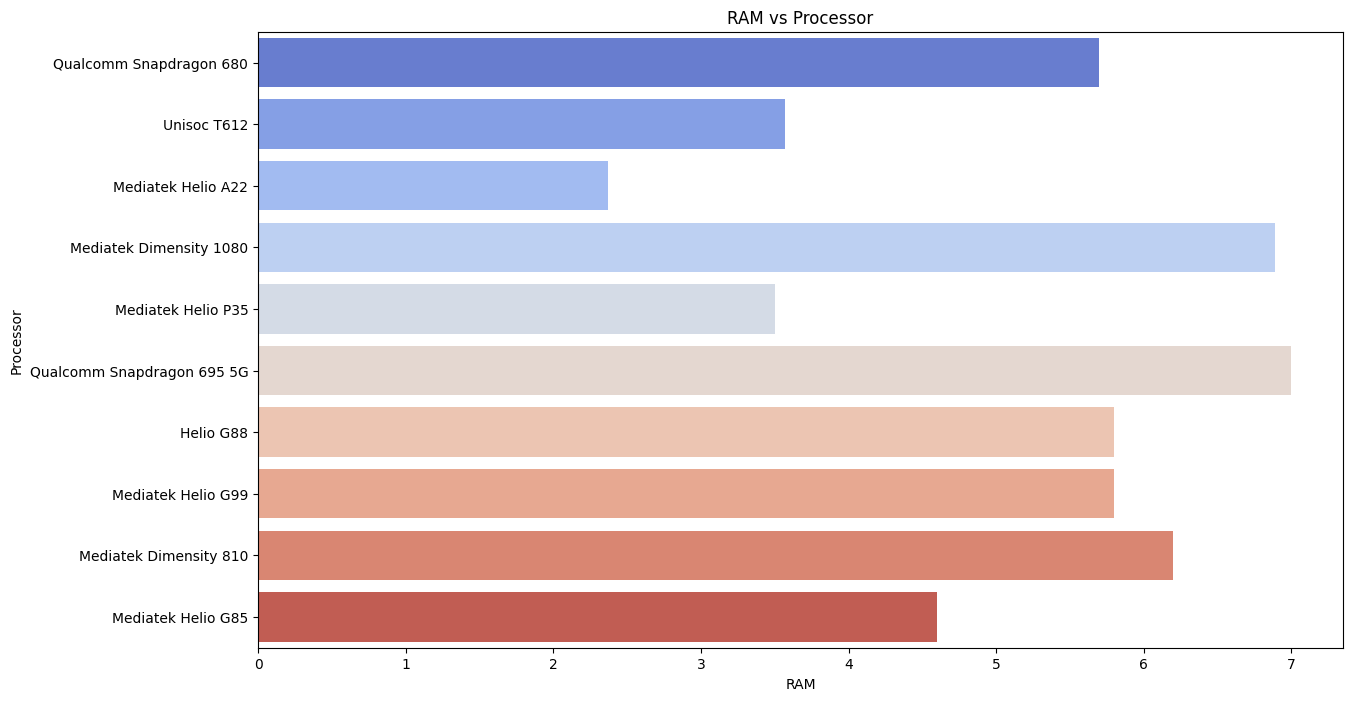

In [63]:
# RAM vs Processor - need fix
top_10_names = df['Processor'].value_counts().head(10).index
df_top_proc = df[df['Processor'].isin(top_10_names)]

plt.figure(figsize=(14, 8))
sns.barplot(data=df_top_proc, x='RAM', y='Processor', palette='coolwarm', order=top_10_names, errorbar=None)
plt.title('RAM vs Processor')
plt.show()

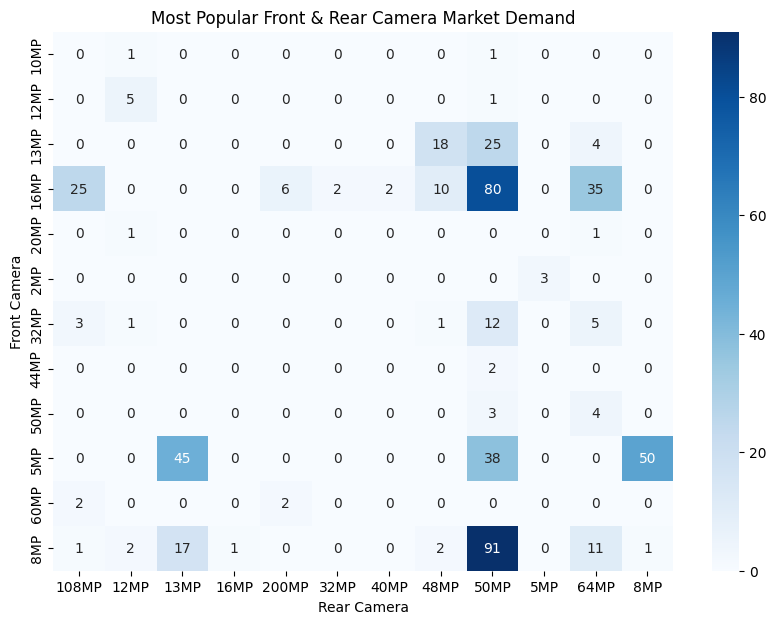

In [64]:
# Relationship between Front and Rear Camera
plt.figure(figsize=(10, 7))
front_rear_camera_table = pd.crosstab(df['Front Camera'], df['Rear Camera'])

# Heatmap
sns.heatmap(front_rear_camera_table, annot=True, fmt='d', cmap='Blues')
plt.title('Most Popular Front & Rear Camera Market Demand')
plt.show()

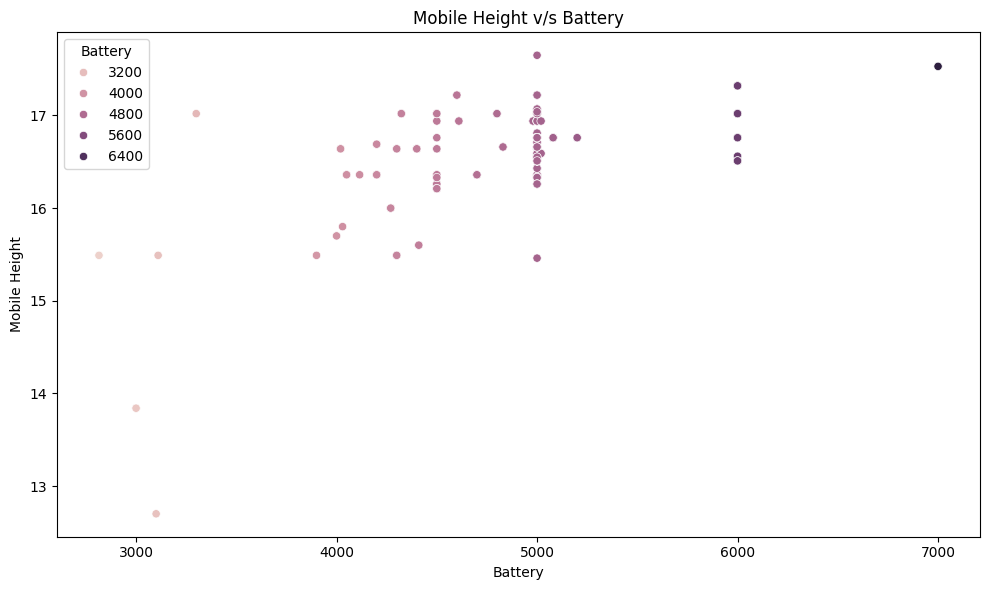

In [100]:
# Battery v/s Mobile Height
fig = plt.figure(figsize=(10, 6))

# # Scatter plot
ax = sns.scatterplot(data=df, x='Battery', y='Mobile Height', hue='Battery')
plt.title("Mobile Height v/s Battery")

plt.tight_layout()
plt.show()

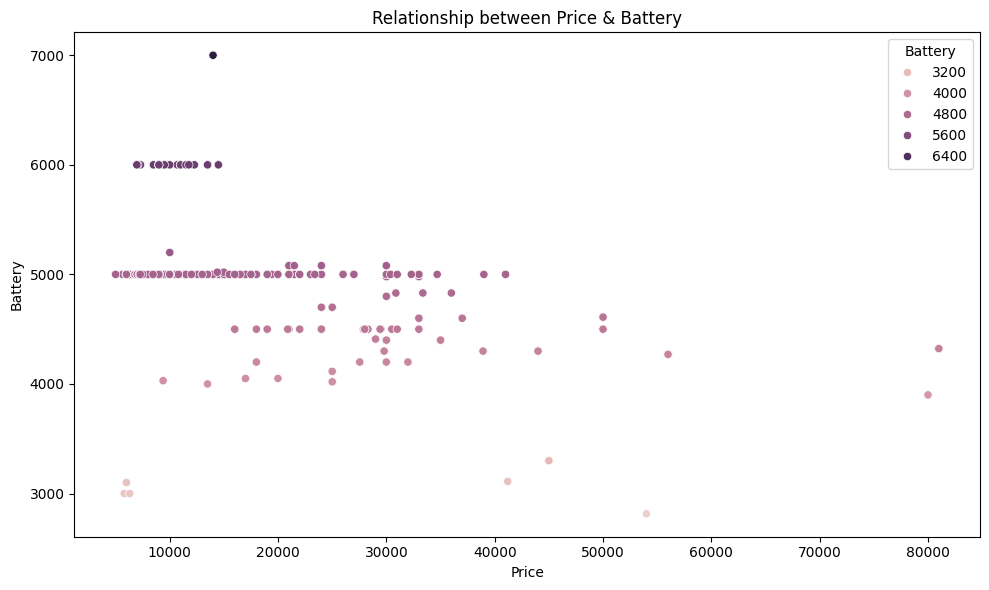

In [101]:
# Battery v/s Price
fig = plt.figure(figsize=(10, 6))

# # Scatter plot
ax = sns.scatterplot(data=df, x='Price', y='Battery', hue='Battery')
plt.title("Relationship between Price & Battery")

plt.tight_layout()
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_10116\3993844122.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_proc, x='Processor', y='Price', palette='coolwarm', order=top_10_names)


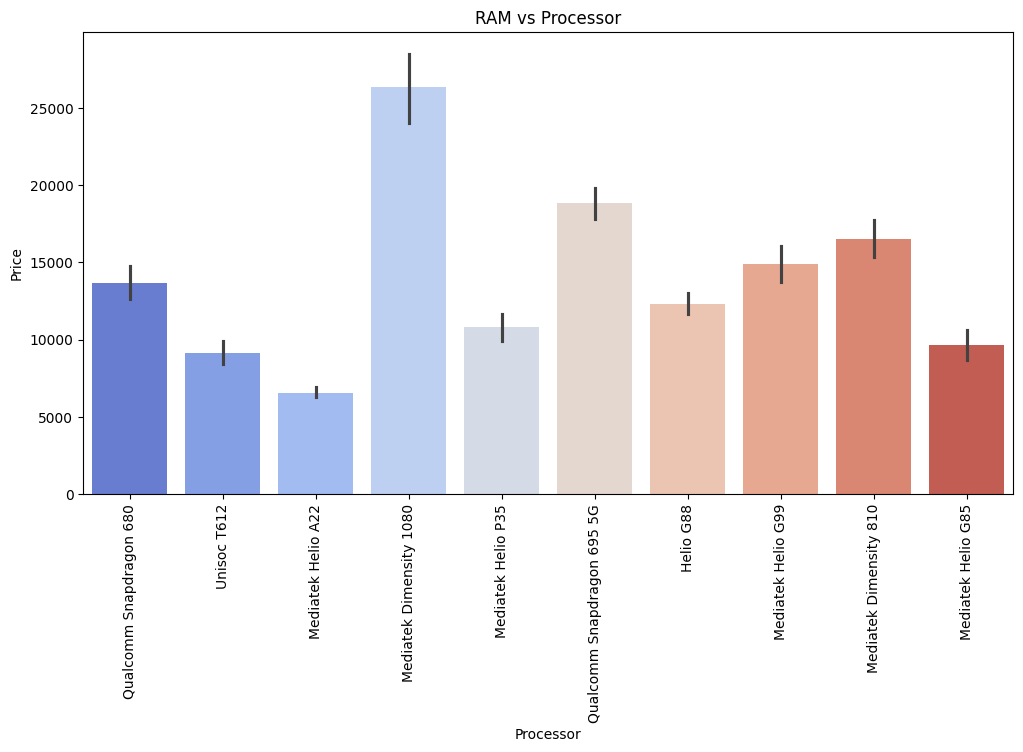

In [103]:

# Processor vs Price
top_10_names = df['Processor'].value_counts().head(10).index
df_top_proc = df[df['Processor'].isin(top_10_names)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_proc, x='Processor', y='Price', palette='coolwarm', order=top_10_names)
plt.title('RAM vs Processor')
plt.xticks(rotation=90)
plt.show()

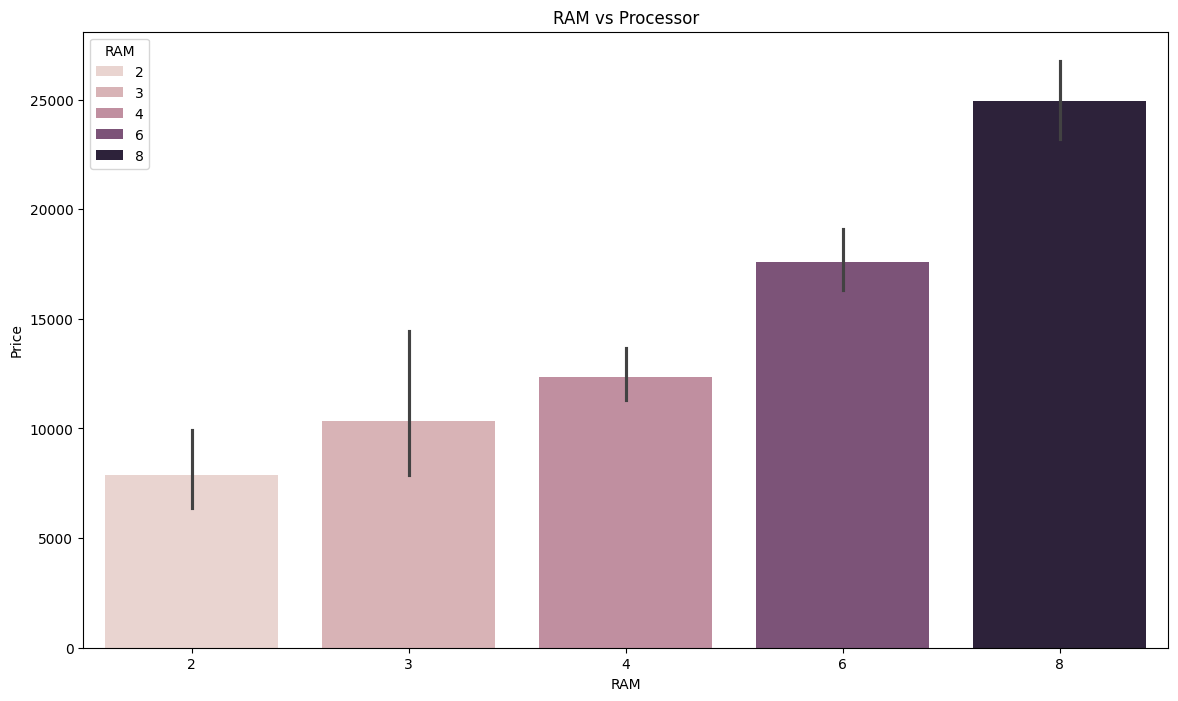

In [104]:
# RAM vs Price
plt.figure(figsize=(14, 8))
sns.barplot(data=df, x='RAM', y='Price', hue='RAM')
plt.title('RAM vs Processor')
plt.show()

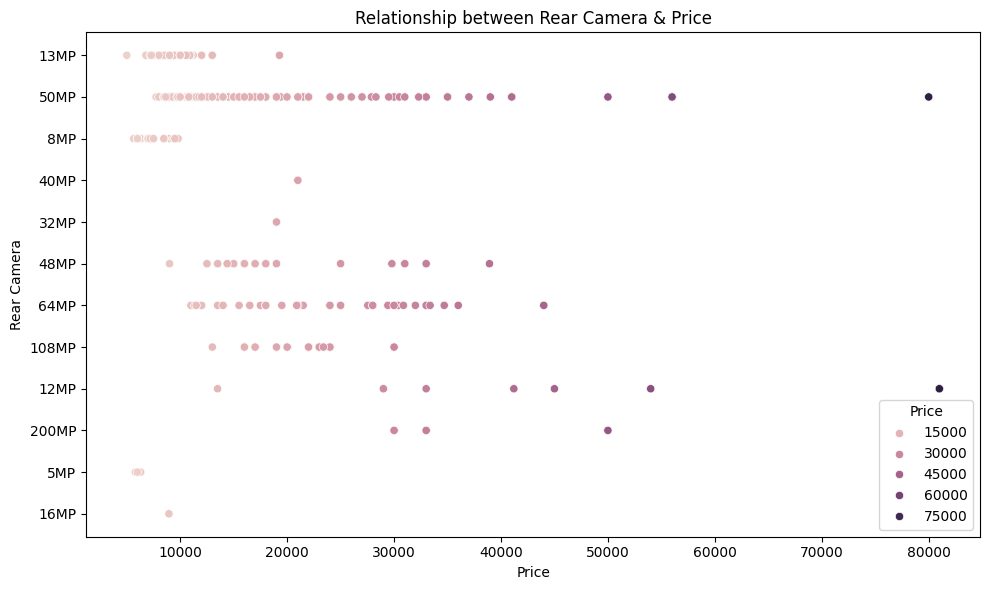

In [105]:
# Rear Camera vs Price
fig = plt.figure(figsize=(10, 6))

# # Scatter plot
ax = sns.scatterplot(data=df, x='Price', y='Rear Camera', hue='Price')
plt.title("Relationship between Rear Camera & Price")

plt.tight_layout()
plt.show()

Multivariate Analysis

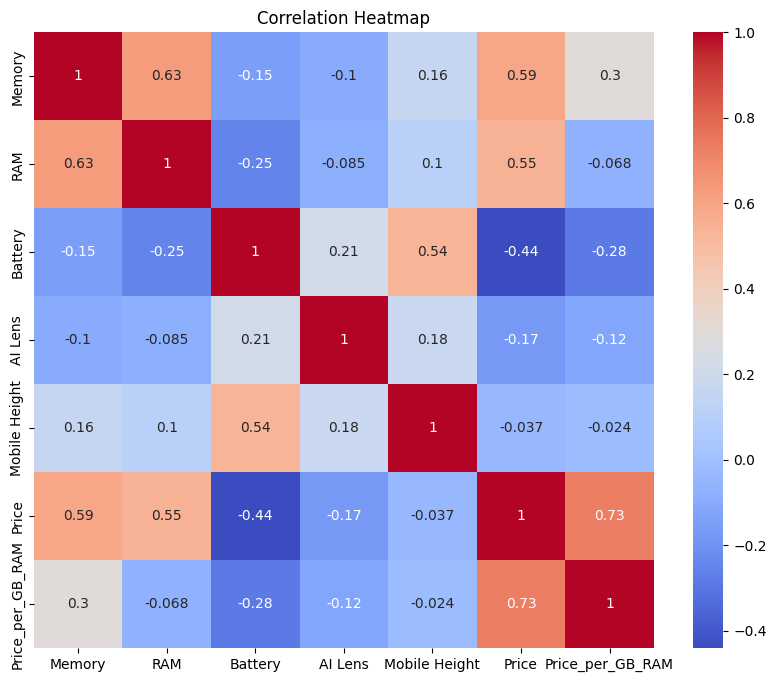

In [106]:
# Heatmap
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

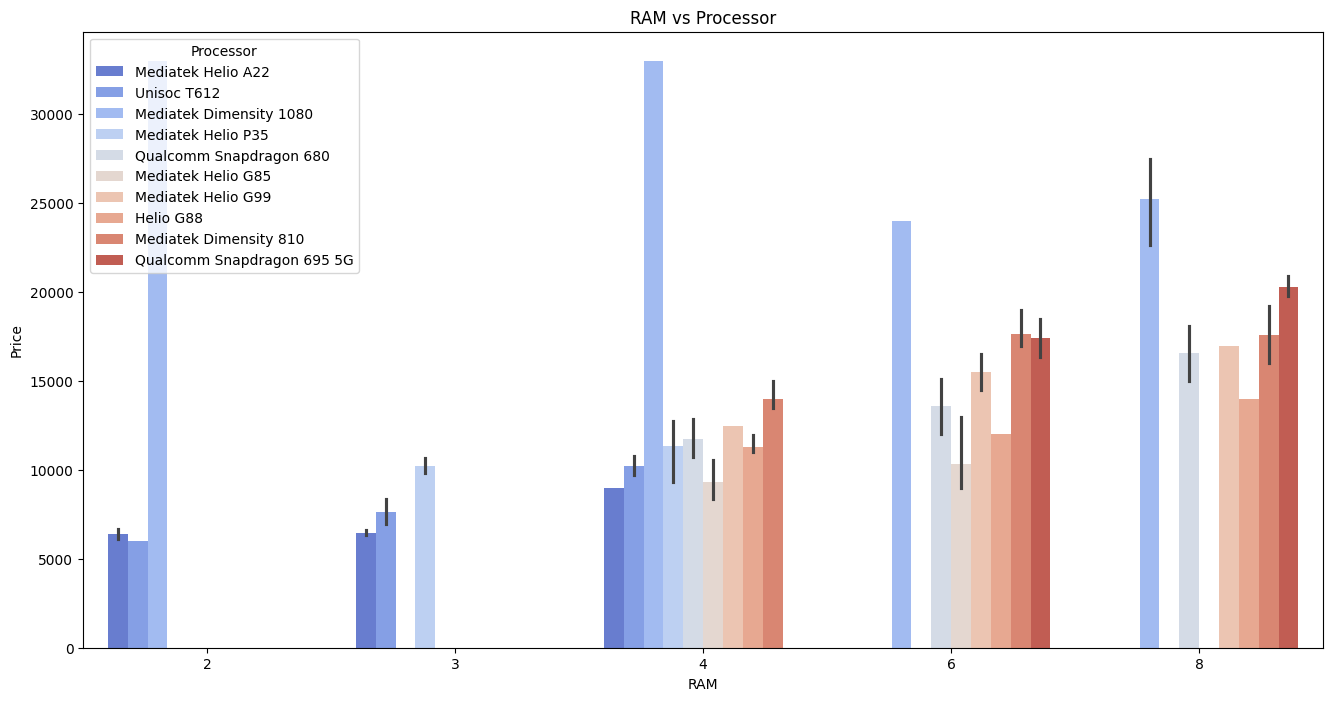

In [107]:
# RAM vs Price with Processor
top_10_names = df['Processor'].value_counts().head(10).index
df_top_proc = df[df['Processor'].isin(top_10_names)]

plt.figure(figsize=(16, 8))
sns.barplot(data=df_top_proc, x='RAM', y='Price', hue='Processor', palette='coolwarm')
plt.title('RAM vs Processor')
plt.show()

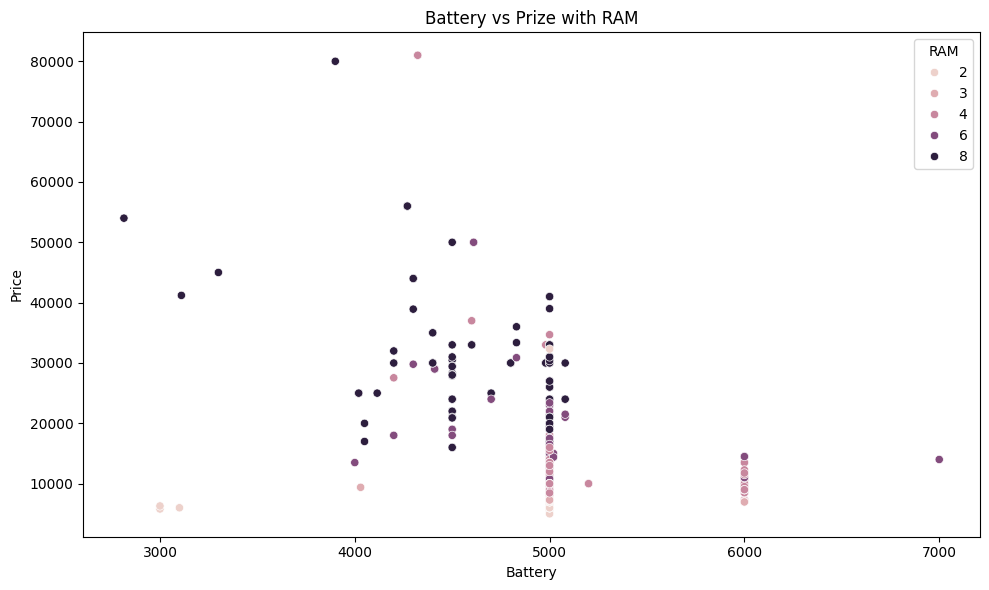

In [109]:
# Battery vs Prize with RAM
fig = plt.figure(figsize=(10, 6))

# # Scatter plot
ax = sns.scatterplot(data=df, x='Battery', y='Price', hue='RAM')
plt.title("Battery vs Prize with RAM")

plt.tight_layout()
plt.show()

Feature engineering

In [76]:
def priceCategory(price):
    if price < 10000:
        return 'Budget'
    elif price <= 25000:
        return 'Mid-Range'
    else:
        return 'Flagship'

# Setting up budget range
df['Price Segment'] = df['Price'].apply(priceCategory)
 

# Processor brand
df['Processor Brand'] = df['Processor'].str.split().str[0]

# Brand name
df['Mobile Brand'] = df['Model'].str.split().str[0]

# Price per GB RAM
df['Price_per_GB_RAM'] = df['Price'] / df['RAM']

df.head()

,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price,Price Segment,Processor Brand,Mobile Brand,Price_per_GB_RAM
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Budget,Unisoc,Infinix,1824.750
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Budget,Unisoc,Infinix,1824.750
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999,Mid-Range,Qualcomm,MOTOROLA,1499.875
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649,Budget,Mediatek,POCO,2824.500
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999,Budget,G37,Infinix,1124.875
